# 07 – Postprocessing: from raw model output to what the user sees

`src/postprocess.py` formalises the steps between the model's probability vector and the keyboard. Typed text is processed with the **same** normalisation and tokenizer as the training data (`src/preprocess.py`, imported, not re-implemented) and the context is the current sentence only.

| stage | function | what it does |
|---|---|---|
| 1 | `raw_topk` | top-k tokens straight from the model: may contain `<unk> <num> <s> </s>`, punctuation; all lowercase |
| 2 | `filter_tokens` | remove special tokens and punctuation |
| 3 | `prefix_filter` | if the user is mid-word keep only words starting with the typed prefix and renormalise |
| 4 | `restore_case` | capitalise at the start of a sentence; `case_map.json` for proper nouns and words like *I*, *O* |
| 5 | `insert_word` / `insert_punctuation` | replace the partial word with the chosen word + space; no space before punctuation |

Evidence below uses the Shakespeare LSTM (best configuration, seed 42) and the KN trigram on the **test** set. Nothing here is tuned.

In [1]:
import sys, pickle, re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import data as D, evaluate as E, rnn as R, postprocess as PP, preprocess as P

FIG_DIR, TAB_DIR, MODEL_DIR = ROOT / "figures", ROOT / "tables", ROOT / "models"
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
BLUE, ORANGE, GREEN, GREY = "#0072B2", "#D55E00", "#009E73", "#777777"


def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=200, bbox_inches="tight")
    print(f"saved figure -> figures/{name}")


def save_table(df, name, index=False):
    df.to_csv(TAB_DIR / name, index=index, encoding="utf-8")
    print(f"saved table  -> tables/{name}")


vocab = D.load_vocab()
case_map = D.load_case_map()
test = D.load_split("test", vocab=vocab)
net, ck = R.load_run("lstm_h512_l1_d0.5", len(vocab), "cpu")           # CPU: this notebook needs no GPU
lstm = R.RNNPredictor(net, "cpu", name="lstm")
kn3 = pickle.load(open(MODEL_DIR / "kn3.pkl", "rb"))
cand = E.word_ids(vocab)
nonword = np.setdiff1d(np.arange(len(vocab)), cand)                       # special tokens + punctuation
print(f"{len(test):,} test sentences; {len(nonword)} non-word tokens: {[vocab.itos[i] for i in nonword]}")

7,191 test sentences; 10 non-word tokens: ['<s>', '</s>', '<unk>', '<num>', '.', ',', ';', ':', '!', '?']


## 1. The five stages on 8 test-set prefixes
Each prefix comes from a test play, followed by the first letters the user "has typed" of the word that actually comes next (so that the prefix filter and the case restoration have something to do). Mix: 2 sentence starts, 3 words with special casing (*I*, *O*, proper nouns), 3 archaic words. Probabilities: stage 1–2 are the model's; from stage 3 they are renormalised over the kept words.

In [2]:
rng = np.random.default_rng(42)
arch = E.archaic_set()
pools = {"sentence start": [], "special casing": [], "archaic word": []}
for si, s in enumerate(test):
    if len(s) < 8:
        continue
    for i in range(1, len(s) - 1):
        tok = vocab.itos[s[i]]
        if s[i] not in set(cand.tolist()) or len(tok) < 3:
            continue
        if i == 1:
            pools["sentence start"].append((si, i))
        elif case_map.get(tok, tok) != tok and tok not in ("god", ) and i >= 4:
            pools["special casing"].append((si, i))
        elif tok.strip("'") in arch and i >= 4:
            pools["archaic word"].append((si, i))
picks = []
for kind, n in (("sentence start", 2), ("special casing", 3), ("archaic word", 3)):
    pool = pools[kind]
    idx = rng.choice(len(pool), size=n, replace=False)
    picks += [(kind, *pool[j]) for j in idx]

rows = []
for kind, si, i in picks:
    s = test[si]
    toks = vocab.decode(s[1:i])
    target = vocab.itos[s[i]]
    typed = target[: 2 if len(target) >= 4 else 1]
    # the user's text so far: previous words of the sentence (display case), then the typed first letters
    text = (D.restore_case(toks, case_map) + (" " if toks else "")) + (typed.capitalize() if not toks else typed)
    r = PP.suggest(lstm, vocab, text, case_map, k=5, trace=True)
    fmt = lambda lst: " | ".join(f"{t} ({p:.2f})" if isinstance(p, float) else str(t) for t, p in lst)
    st = r["stages"]
    rows.append({"kind": kind, "text typed": text, "actual next word": target,
                 "1 raw top-5": fmt(st["1 raw top-k"]), "2 filtered": fmt(st["2 filtered (words only)"]),
                 "3 prefix + renorm.": fmt(st["3 prefix filter + renormalise"]),
                 "4 case restored": fmt(st["4 case restored"]), "5 inserted (top-1)": st["5 inserted text"][0] if st["5 inserted text"] else ""})
stage_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 70); pd.set_option("display.width", 320)
display(stage_df)
save_table(stage_df, "postproc_stage_table.csv")

,kind,text typed,actual next word,1 raw top-5,2 filtered,3 prefix + renorm.,4 case restored,5 inserted (top-1)
0,sentence start,Ca,caesar,i (0.07) | what (0.04) | o (0.03) | and (0.03) | the (0.02),i (0.07) | what (0.04) | o (0.03) | and (0.03) | the (0.02),call (0.29) | can (0.20) | canst (0.07) | caesar (0.07) | captain ...,Call (0.29) | Can (0.20) | Canst (0.07) | Caesar (0.07) | Captain ...,Call
1,sentence start,F,for,i (0.07) | what (0.04) | o (0.03) | and (0.03) | the (0.02),i (0.07) | what (0.04) | o (0.03) | and (0.03) | the (0.02),for (0.24) | farewell (0.17) | fie (0.06) | fare (0.05) | from (0.04),For (0.24) | Farewell (0.17) | Fie (0.06) | Fare (0.05) | From (0.04),For
2,special casing,"This <unk>, sir, was ca",carthage,a (0.07) | the (0.06) | not (0.06) | he (0.05) | it (0.04),a (0.07) | the (0.06) | not (0.06) | he (0.05) | it (0.04),called (0.17) | call'd (0.16) | caesar (0.12) | carried (0.11) | c...,called (0.17) | call'd (0.16) | Caesar (0.12) | carried (0.11) | C...,"This <unk>, sir, was called"
3,special casing,"His words were these: that Richard, du",duke,and (0.07) | that (0.06) | the (0.05) | i (0.03) | as (0.02),and (0.07) | that (0.06) | the (0.05) | i (0.03) | as (0.02),duke (0.55) | dumb (0.11) | durst (0.08) | during (0.04) | dumaine...,Duke (0.55) | dumb (0.11) | durst (0.08) | during (0.04) | Dumaine...,"His words were these: that Richard, Duke"
4,special casing,"This doom, my lord, if I may judge: let so",somerset,me (0.19) | him (0.16) | it (0.06) | us (0.05) | them (0.05),me (0.19) | him (0.16) | it (0.06) | us (0.05) | them (0.05),sorrow (0.51) | some (0.28) | so (0.07) | something (0.03) | soldi...,sorrow (0.51) | some (0.28) | so (0.07) | something (0.03) | soldi...,"This doom, my lord, if I may judge: let sorrow"
5,archaic word,"Shall I abide in this dull world, which in t",thy,the (0.25) | a (0.07) | his (0.05) | my (0.05) | this (0.04),the (0.25) | a (0.07) | his (0.05) | my (0.05) | this (0.04),the (0.62) | this (0.10) | thy (0.05) | these (0.05) | their (0.04),the (0.62) | this (0.10) | thy (0.05) | these (0.05) | their (0.04),"Shall I abide in this dull world, which in the"
6,archaic word,"Who seeks, and will not take when once 'tis offered, sh",shall,and (0.05) | or (0.03) | i (0.03) | that (0.02) | to (0.02),and (0.05) | or (0.03) | i (0.03) | that (0.02) | to (0.02),she (0.41) | shall (0.13) | she's (0.07) | should (0.07) | show (0...,she (0.41) | shall (0.13) | she's (0.07) | should (0.07) | show (0...,"Who seeks, and will not take when once 'tis offered, she"
7,archaic word,"A messenger from Henry, our dread liege, to know the reason of the...",thy,thee (0.11) | him (0.11) | me (0.07) | you (0.06) | the (0.05),thee (0.11) | him (0.11) | me (0.07) | you (0.06) | the (0.05),thee (0.40) | the (0.18) | them (0.16) | to (0.07) | this (0.05),thee (0.40) | the (0.18) | them (0.16) | to (0.07) | this (0.05),"A messenger from Henry, our dread liege, to know the reason of the..."


saved table  -> tables/postproc_stage_table.csv


## 2. How often is the raw top-1 a special token or punctuation?
For every position of the test set (every token after `<s>`, 107k positions) we take the argmax of the *raw* distribution. A keyboard that showed it unfiltered would regularly suggest a comma or `</s>`. "Any of raw top-3" is the share of positions where at least one of the three chips would be a non-word.

,model,positions,raw top-1 is special/punct (%),any of raw top-3 is special/punct (%),targets that are words (%)
0,LSTM,108336,39.03,53.56,74.98
1,KN trigram,108336,40.74,59.23,74.98


saved table  -> tables/postproc_raw_special_rate.csv


saved figure -> figures/postproc_raw_special_rate.png


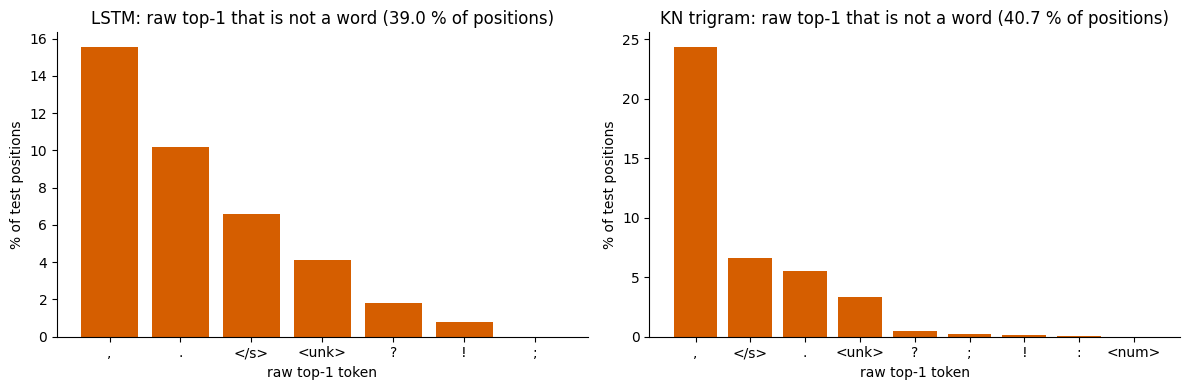

In [3]:
def passes(model, fast):
    """yield (target ids, probability matrix) per test sentence"""
    if fast:
        for s, Pm in zip(test, model.iter_sentence_probs(test)):
            yield np.asarray(s[1:]), Pm
    else:
        for s in test:
            yield np.asarray(s[1:]), np.stack([model.next_word_probs(s[:i]) for i in range(1, len(s))])


stats = {}
for label, model, fast in (("LSTM", lstm, True), ("KN trigram", kn3, False)):
    raw1, filt1, top3_bad, tgt_word = [], [], [], []
    for tgt, Pm in passes(model, fast):
        raw1.append(Pm.argmax(1))
        filt1.append(cand[Pm[:, cand].argmax(1)])
        top3 = np.argpartition(-Pm, 3, axis=1)[:, :3]
        top3_bad.append(np.isin(top3, nonword).any(1))
        tgt_word.append(np.isin(tgt, cand))
    stats[label] = {"raw1": np.concatenate(raw1), "filt1": np.concatenate(filt1),
                    "top3_bad": np.concatenate(top3_bad), "tgt_word": np.concatenate(tgt_word)}
rows = []
for label, d in stats.items():
    bad = np.isin(d["raw1"], nonword)
    rows.append({"model": label, "positions": len(bad), "raw top-1 is special/punct (%)": 100 * bad.mean(),
                 "any of raw top-3 is special/punct (%)": 100 * d["top3_bad"].mean(),
                 "targets that are words (%)": 100 * d["tgt_word"].mean()})
special_df = pd.DataFrame(rows).round(2)
display(special_df)
save_table(special_df, "postproc_raw_special_rate.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, d) in zip(axes, stats.items()):
    c = Counter(vocab.itos[i] for i in d["raw1"] if i in set(nonword.tolist()))
    items = c.most_common()
    ax.bar([t for t, _ in items], [100 * n / len(d["raw1"]) for _, n in items], color=ORANGE)
    ax.set_title(f"{label}: raw top-1 that is not a word ({100 * sum(c.values()) / len(d['raw1']):.1f} % of positions)")
    ax.set_ylabel("% of test positions"); ax.set_xlabel("raw top-1 token")
plt.tight_layout(); save_fig(fig, "postproc_raw_special_rate.png"); plt.show()

## 3. Raw vs filtered predictions vs actual words
Word clouds of the LSTM's **raw** top-1 predictions over the test set, of its top-1 **after filtering**, and of the **actual target words** (word targets). The models over-predict a handful of very frequent items; the table shows how concentrated the predictions are compared with the real text.

saved figure -> figures/postproc_wordclouds.png


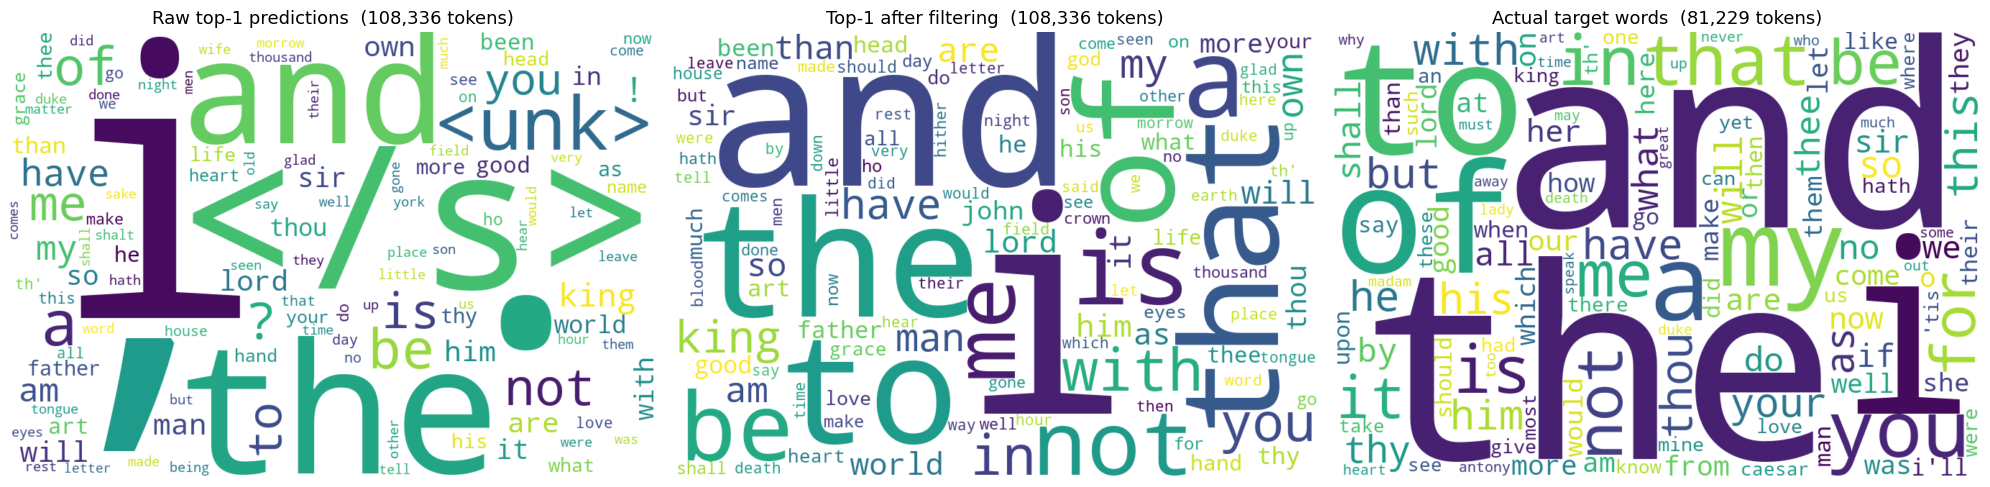

,set,distinct tokens,top-5 tokens' share (%),top-10 share (%),five most frequent
0,raw top-1,623,50.5,67.8,",, i, ., </s>, the"
1,filtered top-1,831,46.4,62.8,"i, and, the, to, that"
2,actual targets,6536,13.1,20.4,"the, and, i, to, of"


saved table  -> tables/postproc_prediction_concentration.csv


In [4]:
d = stats["LSTM"]
raw_c = Counter(vocab.itos[i] for i in d["raw1"])
filt_c = Counter(vocab.itos[i] for i in d["filt1"])
tgt_ids = np.concatenate([np.asarray(s[1:]) for s in test])
tgt_c = Counter(vocab.itos[i] for i in tgt_ids[np.isin(tgt_ids, cand)])
fig, axes = plt.subplots(1, 3, figsize=(20, 5.6))
for ax, cnt, ttl in zip(axes, (raw_c, filt_c, tgt_c), ("Raw top-1 predictions", "Top-1 after filtering", "Actual target words")):
    wc = WordCloud(width=900, height=620, background_color="white", max_words=120, colormap="viridis",
                   random_state=42).generate_from_frequencies(dict(cnt))
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off"); ax.set_title(f"{ttl}  ({sum(cnt.values()):,} tokens)", fontsize=13)
plt.tight_layout(); save_fig(fig, "postproc_wordclouds.png"); plt.show()

top = lambda c, n: sum(x for _, x in c.most_common(n)) / sum(c.values())
conc = pd.DataFrame([
    {"set": "raw top-1", "distinct tokens": len(raw_c), "top-5 tokens' share (%)": 100 * top(raw_c, 5), "top-10 share (%)": 100 * top(raw_c, 10),
     "five most frequent": ", ".join(t for t, _ in raw_c.most_common(5))},
    {"set": "filtered top-1", "distinct tokens": len(filt_c), "top-5 tokens' share (%)": 100 * top(filt_c, 5), "top-10 share (%)": 100 * top(filt_c, 10),
     "five most frequent": ", ".join(t for t, _ in filt_c.most_common(5))},
    {"set": "actual targets", "distinct tokens": len(tgt_c), "top-5 tokens' share (%)": 100 * top(tgt_c, 5), "top-10 share (%)": 100 * top(tgt_c, 10),
     "five most frequent": ", ".join(t for t, _ in tgt_c.most_common(5))}]).round(1)
display(conc)
save_table(conc, "postproc_prediction_concentration.csv")

## 4. Case-restoration accuracy
For every test position where the LSTM's top-1 word is **correct**, the restored display form (stage 4: capital at the start of a sentence, `case_map.json` otherwise) is compared with the original casing in the **pre-lowercasing stage-7 text** (`data/interim/stage7_tokenized`). Two simple baselines for reference: leave everything lowercase; capitalise only at the start of a sentence.

In [5]:
split_df = pd.read_csv(ROOT / "data" / "split.csv"); meta = pd.read_csv(ROOT / "data" / "metadata.csv")
test_slugs = set(split_df.loc[split_df["split"] == "test", "slug"])
cased = []
for slug in meta["slug"]:                                                  # same work order as data/processed/test.txt
    if slug in test_slugs:
        cased += [l.split() for l in (ROOT / "data" / "interim" / "stage7_tokenized" / f"{slug}.txt").read_text(encoding="utf-8").splitlines() if l.strip()]
assert len(cased) == len(test) and all(len(c) == len(s) - 2 for c, s in zip(cased, test))      # s has <s> and </s> around the tokens

In [6]:
r = E.evaluate(lstm, "test", vocab, log=False, details=True)
det = r["details"]
rows = []
for sent, pos, tgt, rank in zip(det["sent"], det["pos"], det["target"], det["rank"]):
    orig = cased[sent][pos - 1]
    low = vocab.itos[tgt]
    assert orig.lower() == low, (orig, low)
    restored = PP.restore_case(low, pos == 1, case_map)
    rows.append((rank == 1, pos == 1, orig, low, restored))
cr = pd.DataFrame(rows, columns=["correct_top1", "sentence_start", "original", "lower", "restored"])
cr["ok_restored"] = cr["original"] == cr["restored"]
cr["ok_lowercase"] = cr["original"] == cr["lower"]
cr["ok_start_only"] = cr["original"] == cr.apply(lambda x: PP.capitalize_first_letter(x["lower"]) if x["sentence_start"] else x["lower"], axis=1)


def summarize(g, label):
    return {"subset": label, "n": len(g), "stage-4 restoration (%)": 100 * g["ok_restored"].mean(),
            "all lowercase (%)": 100 * g["ok_lowercase"].mean(), "capitalise sentence start only (%)": 100 * g["ok_start_only"].mean()}


hit = cr[cr["correct_top1"]]
res = pd.DataFrame([summarize(hit, "correctly predicted words (top-1)"),
                    summarize(hit[hit["sentence_start"]], "  ... at a sentence start"),
                    summarize(hit[~hit["sentence_start"]], "  ... mid-sentence"),
                    summarize(cr, "all word targets (for reference)")]).round(2)
display(res)
save_table(res, "postproc_case_accuracy.csv")

bad = hit[~hit["ok_restored"]]
print(f"{len(bad):,} of {len(hit):,} restorations differ from the original. Most frequent mismatches (original -> restored):")
display(bad.groupby(["original", "restored"]).size().sort_values(ascending=False).head(12).rename("count").reset_index())

# Gutenberg capitalises the first word of every VERSE LINE ("And", "To", "The" ... mid-sentence): a capitalised original
# whose restored form is plain lowercase is almost always such a line-initial capital, not a real casing error.
verse_like = bad[bad["original"].str[0].str.isupper() & (bad["restored"] == bad["lower"])]
adj = 100 * (hit["ok_restored"].sum() + len(verse_like)) / len(hit)
print(f"{len(verse_like):,} of the {len(bad):,} mismatches ({100 * len(verse_like) / len(bad):.0f} %) are a capitalised original where we "
      f"output lowercase (typical verse-line initials); counting them as correct (an estimate), accuracy would be {adj:.1f} %.")
res_adj = pd.DataFrame([{"correctly predicted words": len(hit), "stage-4 accuracy (%)": 100 * hit["ok_restored"].mean(),
                         "mismatches": len(bad), "probable verse-line capitals": len(verse_like),
                         "adjusted accuracy (%) - estimate": adj}]).round(2)
display(res_adj)
save_table(res_adj, "postproc_case_accuracy_adjusted.csv")

,subset,n,stage-4 restoration (%),all lowercase (%),capitalise sentence start only (%)
0,correctly predicted words (top-1),11268,92.83,80.16,85.00
1,... at a sentence start,546,100.00,0.00,100.00
2,... mid-sentence,10722,92.46,84.24,84.24
3,all word targets (for reference),81229,93.43,80.97,89.45


saved table  -> tables/postproc_case_accuracy.csv
808 of 11,268 restorations differ from the original. Most frequent mismatches (original -> restored):


,original,restored,count
0,And,and,467
1,To,to,61
2,The,the,41
3,Of,of,37
4,Than,than,24
5,As,as,23
6,Lord,lord,22
7,That,that,21
8,Is,is,19
9,With,with,19


798 of the 808 mismatches (99 %) are a capitalised original where we output lowercase (typical verse-line initials); counting them as correct (an estimate), accuracy would be 99.9 %.


,correctly predicted words,stage-4 accuracy (%),mismatches,probable verse-line capitals,adjusted accuracy (%) - estimate
0,11268,92.83,808,798,99.91


saved table  -> tables/postproc_case_accuracy_adjusted.csv


## Summary of findings

1. **Why filtering is needed:** the raw top-1 of the LSTM is a special token or punctuation mark at **39.0 %** of the 108,336 test positions (KN trigram 40.7 %), most often a comma, a full stop or `</s>`; at **53.6 %** of positions (KN 59.2 %) at least one of the raw top-3 is a non-word. Only 75.0 % of the real next tokens are words, so an unfiltered keyboard would often show a comma where the user wants a word.
2. **The five stages in practice (8 test prefixes):** filtering removes the junk, the prefix filter then restricts and renormalises (e.g. typing *Ca* at the start of a sentence turns *i / what / o …* into *call / can / …*, probabilities sum to 1 over the matching words), case restoration capitalises sentence starts and proper nouns (*Hamlet*, *I*, *O*), and insertion adds the word plus a space, with no space before a following punctuation mark.
3. **Bias toward frequent words:** the LSTM's filtered top-1 predictions use only 831 distinct words, and five words (*i, and, the, to, that*) make up 46 % of them, whereas the actual next words cover 6,536 distinct words and their five most frequent (*the, and, i, to, of*) account for 13 % – the word clouds show the same concentration. This is a property of arg-max prediction and is why the keyboard shows three suggestions.
4. **Case restoration:** for correctly predicted words the restored casing equals the original in the pre-lowercasing text for **92.8 %** (11,268 words), against 80.2 % if everything stays lowercase and 85.0 % if only sentence starts are capitalised; at sentence starts it is 100 % (546 words), mid-sentence 92.5 % (vs 84.2 % lowercase).
5. **The remaining "errors" are mostly typography:** 798 of the 808 mismatches (99 %) are capitalised originals where we output lowercase, mainly *And* (467), *To* (61), *The* (41), *Of* (37) – the first word of a verse line, which Gutenberg capitalises mid-sentence. Counting them as correct would give at most 99.9 %; this is an upper bound because it also absorbs a few genuine cases such as *Lord* or *King* in forms of address.
6. **Limitations:** the case map comes from the train plays only (a word never seen mid-sentence in train keeps its lowercase form), and a capital letter typed by the user is respected but the model never learns to predict casing itself.